In [47]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris 

In [48]:
class Model(nn.Module):
    def __init__(self, in_features=4 ,h1=8 ,h2=9 , out_features=3 ):
        super().__init__() #call parent constructor 
        self.fc1 = nn.Linear(in_features, h1) #first hidden layer 
        self.fc2 = nn.Linear(h1, h2) #second hidden layer
        self.out = nn.Linear(h2,out_features) #output layer 

    def forward(self, x): #forward pass
        
        # relu - rectified linear unit
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [49]:
model = Model()

In [50]:
iris = load_iris()
df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [51]:
X = df.drop("target",axis=1)
y=df['target']

In [52]:
import numpy as np
X = X.values
y = y.values

In [53]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=41)

In [54]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [55]:
#set the criterion of model to measure the error, how far off the predictions are from the data 
criterion = nn.CrossEntropyLoss()
#Choose Adam(popular one) Optimizer , lr = learning rate(if error doesnt go down after a bunch of iterations(epochs), lower our Learning rate )
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [56]:
#train our model 
# Epochs - One run thru all the training data in our network 
epochs = 100
losses = []
for i in range(epochs):
    # Go forward and get prediction
    y_pred = model.forward(X_train) 

    # Measure the loss/error, gonna be high at first 
    loss = criterion(y_pred, y_train) #predicted vs train 
    losses.append(loss.detach().numpy())

    #print every 10 epoch 
    if i % 10 == 0:
        print(f'Epoch {i} and loss: {loss}')

    # Do some back propagation : take the error rate of forward propogation and feed it back through the network to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Epoch 0 and loss: 1.1095489263534546
Epoch 10 and loss: 1.0749969482421875
Epoch 20 and loss: 0.9695098400115967
Epoch 30 and loss: 0.7616117000579834
Epoch 40 and loss: 0.5961865186691284
Epoch 50 and loss: 0.5297353863716125
Epoch 60 and loss: 0.49913135170936584
Epoch 70 and loss: 0.4837760031223297
Epoch 80 and loss: 0.4755171835422516
Epoch 90 and loss: 0.4707106649875641


Text(0, 0.5, 'loss/error')

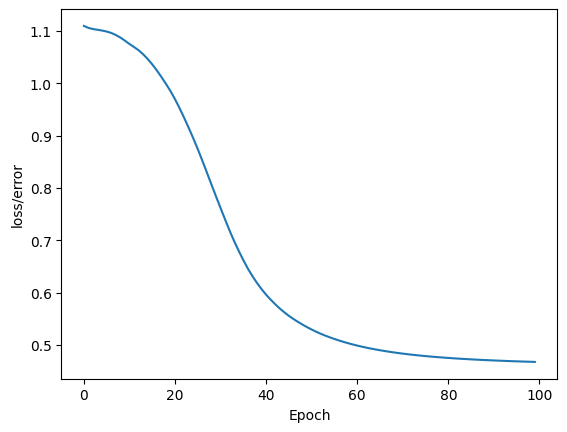

In [57]:
#Graph 
plt.plot(range(epochs), losses)
plt.xlabel("Epoch")
plt.ylabel("loss/error")

In [58]:
#Evaluate Model
with torch.no_grad():
    y_eval = model.forward(X_test)
    loss = criterion(y_eval , y_test)

In [59]:
loss

tensor(0.5019)

In [64]:
correct = 0 
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        print(f"{i+1} .) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}")

        if y_val.argmax().item() == y_test[i]:
            correct +=1  
print(f"correct: {correct}")

1 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
2 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
3 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
4 .) tensor([-2.0287,  1.3878,  1.4026]) 	 1 	 2
5 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
6 .) tensor([-2.0287,  1.3878,  1.4026]) 	 1 	 2
7 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
8 .) tensor([-2.0287,  1.3878,  1.4026]) 	 1 	 2
9 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
10 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
11 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
12 .) tensor([ 3.8011, -4.4848, -3.0342]) 	 0 	 0
13 .) tensor([ 3.2136, -3.8924, -2.5869]) 	 0 	 0
14 .) tensor([-2.0287,  1.3878,  1.4026]) 	 1 	 2
15 .) tensor([ 2.6170, -3.2910, -2.1326]) 	 0 	 0
16 .) tensor([-2.0287,  1.3878,  1.4026]) 	 2 	 2
17 .) tensor([ 3.0793, -3.7570, -2.4846]) 	 0 	 0
18 .) tensor([-2.0287,  1.3878,  1.4026]) 	 1 	 2
19 .) tensor([ 4.5889, -5.2894, -3.6351]) 	 0 	 0
20 .) tensor([ 1.2835, -1.9465, -1.1173]) 	 0 	 0
21 .) ten